In [2]:
import os
import sys

# sys.path.append(os.path.join(os.path.dirname(__file__), '../../'))

from regpy.hilbert import L2, Sobolev
from regpy.vecsps import UniformGridFcts, GridFcts
from regpy.solvers import RegularizationSetting
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.operators import FourierTransform
import regpy.stoprules as rules
from regpy.operators import Exponential, SquaredModulus
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#from regpy.operators.fresnel import fresnel_propagator
import matplotlib.animation as animation
import time

from x_ray_phase_contrast import Corr, _build_fresnel_2, fresnel_prop, Ptw_Multiplication, Mat, Theta, Tau, Proj

import numpy as np
from math import floor
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

################################################ Initialization parameters ################################
N=256               # Pixel numbers
M=10                # Shots per frame
N_frame=1000        # Number of frames ( or realizations)
T=10**12            # the observation time or the number of photon counts
fresnel_number=1e-3   # not properly scaled
coherence_len = 0.3 # coherence length
N_b=2             # denotes the rank of the matrix V
Newton_steps =5    # Number of Newton updates
CG_steps=15         # Number of Conjugate gradient steps
N_ADMM=10          # Number of ADMM iterations
sigma=0.5           # parameter used in the rapid deacaying function
gamma=2           # proximity parameter
 ############################################################################
# perform a uniform grid
xsample=np.arange(-1,1-1/N,2/N)
ysample=xsample
grid=UniformGridFcts(xsample, ysample, dtype=complex)
# perform frequencies in a uniform grid
# freq = grid.frequencies()
# perform Fresenel propagation operator
fp=fresnel_prop(grid, number=complex(0, 1)/(2*fresnel_number))
    
create_type='fourier_random'
# create random vector V in spatial and frequency domain
if create_type=='spatial':
    # create random vector V ( we suppose that K=VV* and V has small rank N_b)
    vec=np.zeros((N_b, N, N), dtype=complex)
    for i in range(0, N_b):
        vec[i, :, :]=1/np.sqrt(2)*(np.random.randn(N**2).reshape(N, N)+complex(0,1)*np.random.randn(N**2).reshape(N, N))
        #vec[i, :, :] = 1/np.sqrt(2)*grid.randn()
    #Multiply with a rapid decaying function
    vec=vec*np.exp(-(xsample)**2/(2*sigma**2)).reshape(N, 1)*np.exp(-(ysample)**2/(2*sigma**2)).reshape(1, N)
    #perform singular value decomposition ( a process to find PCA)
    U, S, V=np.linalg.svd(vec.reshape(N_b, N**2), full_matrices=False)
    # Vcov defines the orthogonal eigenvector (i.e., the principal components)))
    Vcov=V.T.conj()*S
elif create_type=='Fresnelprop':
    col=fresnel_prop(grid, coherence_len**2)
    conv=np.zeros((N_b, N, N), dtype=complex)
    for i in range(0, N_b):    
        fjsq=np.random.randn(N**2).reshape(N, N)
        conv[i, :, :]=col(fjsq)
# The eigenvectors are being orthonormalized    
    U, S, V=np.linalg.svd(conv.reshape(N_b, N**2), full_matrices=False)
    Vcov=V.T.conj()*S
    
elif create_type=='fourier_random':
    

    fourier=FourierTransform(grid, centered=True)
    #Multiply with the Gaussian function in Fourier domain,
    func_freq=np.exp(-np.linalg.norm(fourier.codomain.coords, axis=0)**2/sigma**2)

#defines the cut-off function, e.g., the bump function
    def cutoff_function_2d(x, y):
        xx,yy = np.meshgrid(x,y)
        mask=((1-xx**2-yy**2)>0)
        func=np.zeros(xx.shape)
        func[mask]=(np.exp(1)*np.exp(-1/(1-xx**2-yy**2)))[mask]
        return func

# perform the cut-off function  
    vec_cut=cutoff_function_2d(xsample,ysample)
    # defines the vector V in the spatial domain after performing inverse Fourier transform
    vec_cutted=np.zeros((N_b, N, N), dtype=complex)
    for i in range(0, N_b):
        vec_cutted[i, :, :]=fourier.adjoint(fourier.domain.randn()*func_freq)*vec_cut
    # perform SVD procedure    
    U, S, V=np.linalg.svd(vec_cutted.reshape(N_b, N**2), full_matrices=False)
    Vcov=V.T.conj()*S
    
else:
    raise ValueError('No method specified')
    
# create test images
X,Y = np.meshgrid(xsample, ysample, sparse=False)

#absorp=np.load('cell1.npy')
#phase=np.load('cell2.npy')
absorp=np.load('cell256.npy')
phase=absorp
#support_mask=((abs(X)<=0.801)*(abs(Y)<=0.801)).astype('int')  #constant rectangular bump
support_mask=((abs(X)**2+abs(Y)**2)<=0.6).astype('int')   # constant circular bump
contrast = (0.01+0.01*complex(0,1))*support_mask+(0.1*absorp + 0.2*complex(0,1) * phase)
#grid=UniformGridFcts(xsample, ysample, dtype=complex)
#grid_codomain=UniformGridFcts(N, N, N_b, dtype=complex)
#grid_codomain_2=UniformGridFcts(N, N, N_b, N_b, dtype=complex)
#grid_codomain_3=UniformGridFcts(2, N, N, N_b, N_b, dtype=complex)

# grid=GridFcts(xsample, ysample, dtype=complex)
grid_codomain=GridFcts(N, N, N_b, dtype=complex)
grid_codomain_2=GridFcts(N, N, N_b, N_b, dtype=complex)
grid_codomain_3=GridFcts(2, N, N, N_b, N_b, dtype=complex)
# defines the support of the contrast 
mask=(contrast!=0)
#projection=CoordinateMask(grid, mask)
Mat_op=Mat(grid, grid_codomain, Vcov, fp)
Tau_op=Tau(Mat_op.codomain, grid_codomain_2)
Proj_op=Proj(Tau_op.codomain, grid_codomain_3)
Theta_op=Theta(N, N_b)
#op=Proj_op*Tau_op*Mat_op
op=Tau_op*Mat_op

ptw_detection= SquaredModulus(grid)
mult=Ptw_Multiplication(grid, np.exp(contrast))
ptw_op=ptw_detection*fp*mult 
taumat_0=Mat_op(contrast) 
# create noisy intensity data
intens_tot=np.zeros((N, N))
intensities=np.zeros((N_frame, N, N))

for i in range(0, N_frame):
    print(i)
    signal=np.zeros((N, N))
    for j in range(0, M):
        random=1/np.sqrt(2)*(np.random.randn(N_b)+complex(0,1)*np.random.randn(N_b))
        uinc=np.tensordot(taumat_0, random, axes=([-1], [0]))
        signal+=ptw_detection(uinc)
    
    #Cox-processes
    signal=(1/T)*np.random.poisson(lam=T*signal.flatten(), size=(N**2)).reshape(N, N)
    intens_tot+=signal
    intensities[i, :, :]=signal
    

intensities-=intens_tot/N_frame
# perform the penalty term with L^2-norm and discretization via Gram matrix
gram_type='L2'

if gram_type=='L2':
    def _gram_inv(x):
        return x
    
    def _gram(x):
        return x
    
elif gram_type=='Sobolev':
    from regpy.hilbert import SobolevUniformGridFcts
    
    sobolev_space=SobolevUniformGridFcts(op.domain, index=sobolev_index, axes=None)
    
    _gram=sobolev_space.gram
    _gram_inv=sobolev_space.gram_inv
        
    #def _gram(x):
    #    return projection._adjoint(sobolev_space.gram(projection(x)))
    
    #def _gram_inv(x):
    #    return projection._adjoint(sobolev_space.gram_inv(projection(x)))
    


def _norm(taumat, deriv):
    h=np.random.randn(N**2).reshape(N, N)
    norm = np.sqrt(np.real(np.vdot(h, h)))
    for count in range(10):
        print(count)
        h = h / norm
        
        derivh=deriv(h)
        derivh=M**2*Theta_op._deriv_adjoint(taumat, taumat, Proj_op(derivh))
        h=deriv._adjoint(Proj_op._adjoint(derivh))
        
        norm = np.sqrt(np.real(np.vdot(_gram_inv(h), _gram_inv(h))))
    return np.sqrt(norm)

# defines the conjugate gradient method
def CG_op(backprop, op, taumat, Theta_op, Proj_op, max_iter=5, reg=0, tol=10**(-50), print_residual=True):
    r=_gram_inv(backprop)
    d = r
    counter=0
    x=op.domain.zeros()
    while counter<=max_iter and np.linalg.norm(r)>=tol:
        mat=op(d)
        z_adj_1=M**2*Theta_op._deriv_adjoint(taumat, taumat, Proj_op(mat))
        z_adj=op._adjoint(Proj_op._adjoint(z_adj_1))
        z=_gram_inv(z_adj)+reg*d
        
        normsq_r_old=np.vdot(r, _gram(r)).real
        scalar=np.vdot(d, _gram(z)).real
        alpha=normsq_r_old/scalar
        x = x + alpha*d
        r = r - alpha*z
        beta=np.vdot(r, _gram(r)).real/normsq_r_old
        d = r + beta*d
        if print_residual:
            print('residual=\n',np.linalg.norm(r))
        counter+=1
    return x

def _deriv_adjoint(h, deriv, taumat):        
    derivh=deriv(h)
    derivh=M**2*Theta_op._deriv_adjoint(taumat, taumat, Proj_op(derivh))
    h=deriv._adjoint(Proj_op._adjoint(derivh)) 
    return h       

#inner_reg=1 
# perform ADMM method   
def _ADMM(backprop, gamma, deriv, taumat, alpha, N_ADMM=10):
    x=deriv.domain.zeros()
    Tstarv1=deriv.domain.zeros()
    v2=deriv.domain.zeros()
    Tstarp1=deriv.domain.zeros()
    p2=deriv.domain.zeros()
    for i in range(0, N_ADMM):
        x=CG_op(Tstarv1+Tstarp1+v2+p2, deriv, taumat, Theta_op, Proj_op, max_iter=10, reg=1, tol=10**(-50))
        adjx=_deriv_adjoint(x, deriv, taumat)
        Tstarv1 = 1/(1+1/gamma)*(adjx-backprop-Tstarp1)+backprop
        Tstarp1= Tstarp1-gamma*adjx+gamma*Tstarv1
        v2=_proximal_penalty(x-p2, alpha, 1/gamma)
        p2=p2-gamma*(x-v2)
    return x
# defines the proximity operator with proximity parameter tau    
def _proximal_data(y, tau):
    return 1/(1+tau)*y

#Define different masks
mask_absorp=(contrast.real!=0)
mask_phase=(contrast.imag!=0)

def _proximal_penalty(y, alpha, tau):
    #perform proximal operator
    x=1/(1+tau*alpha)*y
    # perform non-negativity constraint
    x=np.maximum(x.real, 0*x.real)+complex(0,1)*np.maximum(x.imag, 0*x.imag)
    return_x=0*x
    #perform support constraint
    return_x[mask_absorp]+=x.real[mask_absorp]
    return_x[mask_phase]+=complex(0,1)*x.imag[mask_phase]
    return return_x

#perform Newton method for solving the linearized problem
sol_it = np.zeros((N, N), dtype=complex)
for Newton_it in range(Newton_steps):
    print(Newton_it)
    # evaluate forward operator at sol_it
    taumat, deriv=op.linearize(sol_it)
    # apply adjoint to rhs of Newton equation (i.e., back-propagation operator)
    backprop_1=M**2*Theta_op._eval_adjoint(taumat, taumat, Proj_op(taumat))
    backprop_2=M/N_frame*Theta_op._backprop(taumat, taumat, intensities.transpose([1, 2, 0]), intensities.transpose([1, 2, 0]), k_G=N_frame)
    backprop=backprop_2-backprop_1
    backprop=deriv._adjoint(Proj_op._adjoint(backprop))
    #compute approximation to operator norm of linearized forward operator T

    norm=_norm(taumat, deriv)
    if Newton_it==0:
        alpha=norm**2
    else:
        alpha*=0.9
    #Newton_up=_ADMM(backprop, gamma, deriv, taumat, alpha, N_ADMM=10)
    Newton_up=_ADMM(1/norm**2*backprop, gamma, 1/norm*deriv, taumat, alpha=alpha, N_ADMM=N_ADMM)
    #Newton_up=_ADMM(backprop, gamma, deriv, taumat, alpha=alpha, N_ADMM=50)
    
    sol_it = sol_it + Newton_up


/tmp/ipykernel_26005/1958021354.py:89: RuntimeWarning: divide by zero encountered in divide
  func[mask]=(np.exp(1)*np.exp(-1/(1-xx**2-yy**2)))[mask]
/tmp/ipykernel_26005/1958021354.py:89: RuntimeWarning: overflow encountered in exp
  func[mask]=(np.exp(1)*np.exp(-1/(1-xx**2-yy**2)))[mask]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

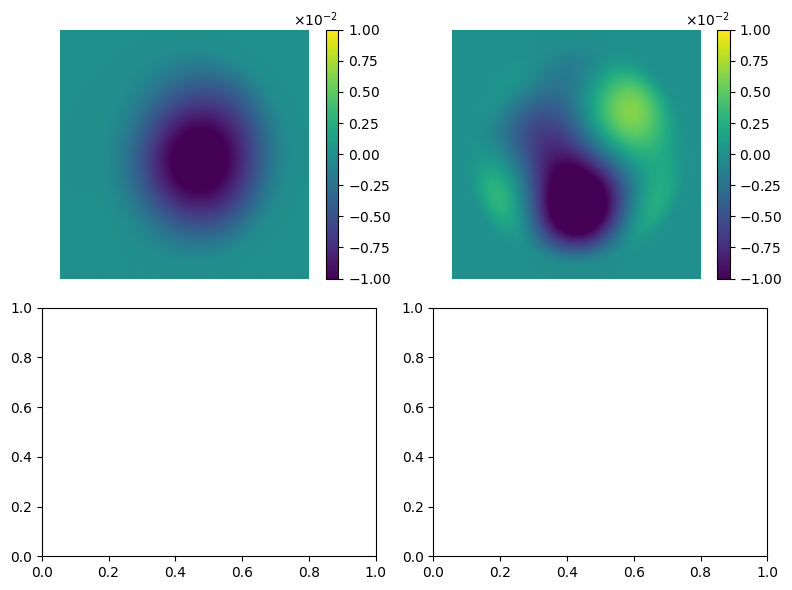

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

# Plot each normalized eigenvectors
im1 = axs[0, 0].imshow(Vcov[:, 0].reshape(N, N).real/ np.linalg.norm(Vcov[:, 0].reshape(N, N).real),vmin=-0.01,vmax=0.01)
axs[0, 0].axis('off')
cbar=fig.colorbar(im1, ax=axs[0, 0])
cbar.formatter.set_powerlimits((0, 0))
# to get 10^3 instead of 1e3
cbar.formatter.set_useMathText(True)

im2 = axs[0, 1].imshow(Vcov[:, 1].reshape(N, N).real/ np.linalg.norm(Vcov[:, 1].reshape(N, N).real),vmin=-0.01,vmax=0.01)
axs[0, 1].axis('off')
cbar=fig.colorbar(im2, ax=axs[0, 1])
cbar.formatter.set_powerlimits((0, 0))
# to get 10^3 instead of 1e3
cbar.formatter.set_useMathText(True)

# im3 = axs[1, 0].imshow(Vcov[:, 2].reshape(N, N).real/ np.linalg.norm(Vcov[:, 2].reshape(N, N).real),vmin=-0.01,vmax=0.01)
# axs[1, 0].axis('off')
# cbar=fig.colorbar(im3, ax=axs[1, 0])
# cbar.formatter.set_powerlimits((0, 0))
# # to get 10^3 instead of 1e3
# cbar.formatter.set_useMathText(True)

# im4 = axs[1, 1].imshow(Vcov[:, 3].reshape(N, N).real/ np.linalg.norm(Vcov[:, 3].reshape(N, N).real),vmin=-0.01,vmax=0.01)
# axs[1, 1].axis('off')
# cbar=fig.colorbar(im4, ax=axs[1, 1])
# cbar.formatter.set_powerlimits((0, 0))
# # to get 10^3 instead of 1e3
# cbar.formatter.set_useMathText(True)
plt.tight_layout()
plt.show()

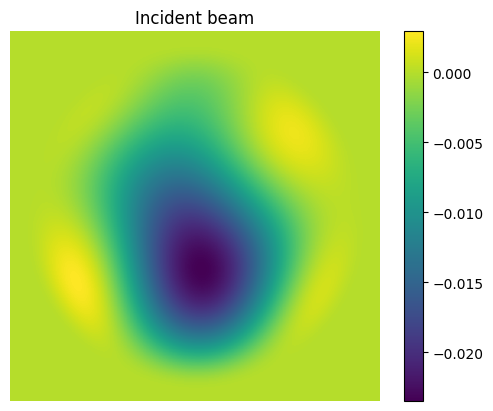

In [4]:
V0=Vcov[:, 0].reshape(N, N).real/ np.linalg.norm(Vcov[:, 0].reshape(N, N).real)
V1=Vcov[:, 1].reshape(N, N).real/ np.linalg.norm(Vcov[:, 1].reshape(N, N).real)                                                
# V2=Vcov[:, 2].reshape(N, N).real/ np.linalg.norm(Vcov[:, 2].reshape(N, N).real)
# V3=Vcov[:, 3].reshape(N, N).real/ np.linalg.norm(Vcov[:, 3].reshape(N, N).real)
U_inci=V0+V1#+V2+V3

plt.figure()
plt.imshow(U_inci)
plt.colorbar()
plt.axis('off')
plt.title('Incident beam')
plt.show()                                              


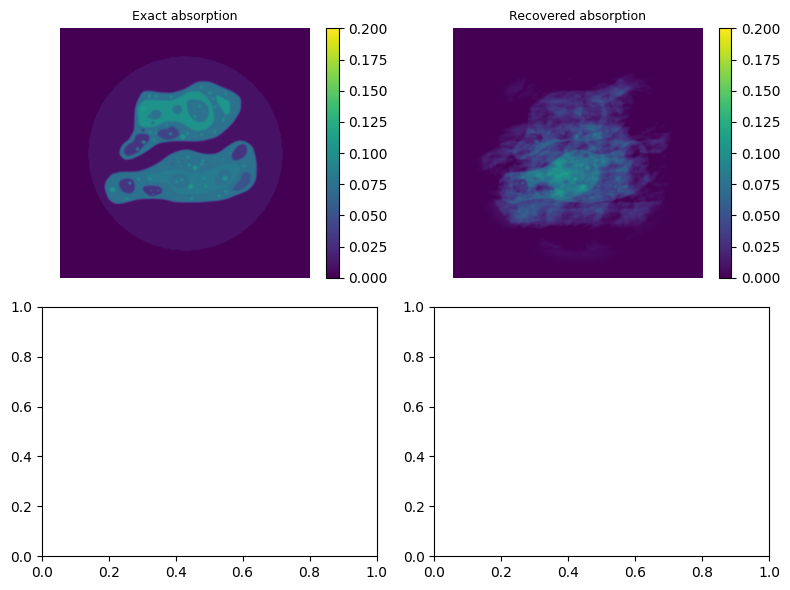

In [5]:
# Create subplots--->reconstructions
vmin=0
vmax=0.2
#cmap='Reds'
fontsize=9
levels=40
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
# Plot each image

im1 = axs[0, 0].imshow(contrast.real, vmin=vmin, vmax=vmax)
axs[0, 0].set_title('Exact absorption',fontsize=fontsize)
axs[0, 0].axis('off')
fig.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(sol_it.real, vmin=vmin, vmax=vmax)
axs[0, 1].set_title('Recovered absorption',fontsize=fontsize)
axs[0, 1].axis('off')
fig.colorbar(im2, ax=axs[0, 1])


# im3 = axs[1, 0].imshow(contrast.imag, vmin=vmin, vmax=vmax)
# axs[1, 0].set_title('Exact phase',fontsize=fontsize)
# axs[1, 0].axis('off')
# fig.colorbar(im3, ax=axs[1, 0])

# im4 = axs[1, 1].imshow(sol_it.imag, vmin=vmin, vmax=vmax)
# axs[1, 1].set_title('Recovered phase',fontsize=fontsize)
# axs[1, 1].axis('off')
# fig.colorbar(im4, ax=axs[1, 1])
# Adjust layou
plt.tight_layout()
#plt.subplot_tool()
plt.show()

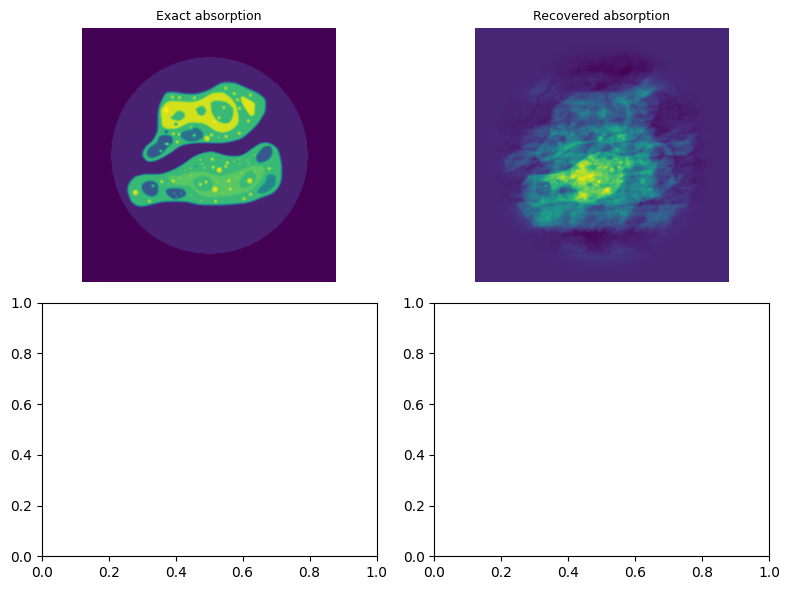

In [6]:
fontsize=9
levels=40
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
# Plot each image

im1 = axs[0, 0].imshow(contrast.real)
axs[0, 0].set_title('Exact absorption',fontsize=fontsize)
axs[0, 0].axis('off')
#fig.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(sol_it.real)
axs[0, 1].set_title('Recovered absorption',fontsize=fontsize)
axs[0, 1].axis('off')
#fig.colorbar(im2, ax=axs[0, 1])


# im3 = axs[1, 0].imshow(contrast.imag)
# axs[1, 0].set_title('Exact phase',fontsize=fontsize)
# axs[1, 0].axis('off')
# #fig.colorbar(im3, ax=axs[1, 0])

# im4 = axs[1, 1].imshow(sol_it.imag)
# axs[1, 1].set_title('Recovered phase',fontsize=fontsize)
# axs[1, 1].axis('off')
#fig.colorbar(im4, ax=axs[1, 1])
# Adjust layou
plt.tight_layout()
#plt.subplot_tool()
plt.show()

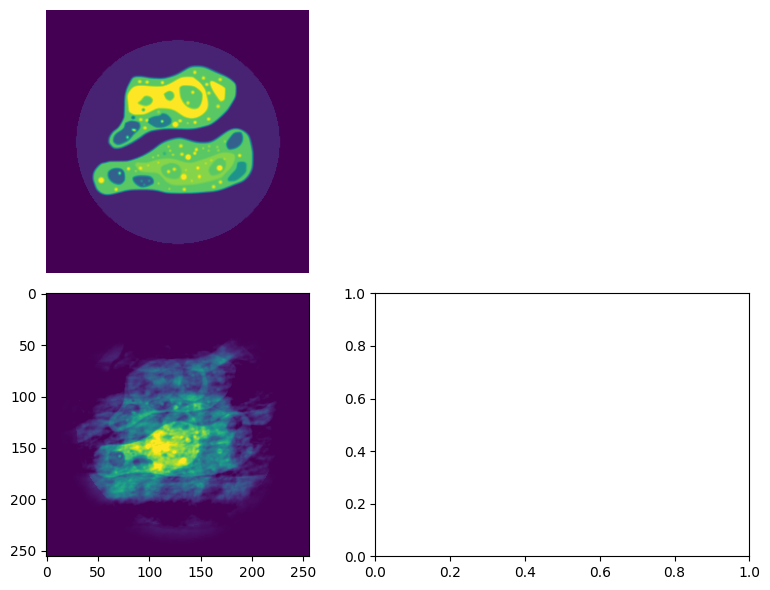

In [7]:
ontsize=14
levels=40
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
# Plot each image

im1 = axs[0, 0].imshow(contrast.real, vmin=0, vmax=0.1)
#axs[0, 0].set_title('Exact absorption',fontsize=fontsize)
axs[0, 0].axis('off')
#fig.colorbar(im1, ax=axs[0, 0])

# im3 = axs[0, 1].imshow(contrast.imag, vmin=0, vmax=0.2)
# #axs[1, 0].set_title('Exact phase',fontsize=fontsize)
# axs[1, 0].axis('off')
# #fig.colorbar(im3, ax=axs[1, 0])

im2 = axs[1, 0].imshow(sol_it.real, vmin=0, vmax=0.1)
#axs[0, 1].set_title('Recovered absorption',fontsize=fontsize)
axs[0, 1].axis('off')
#fig.colorbar(im2, ax=axs[0, 1])


# im4 = axs[1, 1].imshow(sol_it.imag, vmin=0, vmax=0.2)
# #axs[1, 1].set_title('Recovered phase',fontsize=fontsize)
# axs[1, 1].axis('off')
#fig.colorbar(im4, ax=axs[1, 1])
# Adjust layou
plt.tight_layout()
#plt.subplot_tool()
plt.show()

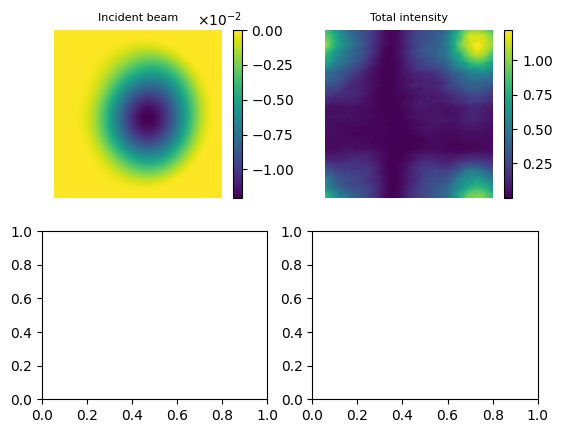

In [8]:
# Create the figure with constrained layout
fig2 = plt.figure(constrained_layout=False)
fontsize=8
# Define the grid for subplots
spec2 = gridspec.GridSpec(ncols=2, nrows=2, figure=fig2)

# Add subplots to the figure
f2_ax1 = fig2.add_subplot(spec2[0, 0])
f2_ax2 = fig2.add_subplot(spec2[0, 1])
f2_ax3 = fig2.add_subplot(spec2[1, 0])
f2_ax4 = fig2.add_subplot(spec2[1, 1])

# Plot the first figure
im1 = f2_ax1.imshow(Vcov[:, 0].reshape(N, N).real/ np.linalg.norm(Vcov[:, 0].reshape(N, N).real))
f2_ax1.axis('off')
f2_ax1.set_title('Incident beam', fontsize=fontsize)
cbar=fig.colorbar(im1, ax=f2_ax1)
cbar.formatter.set_powerlimits((0, 0))
# to get 10^3 instead of 1e3
cbar.formatter.set_useMathText(True)

# Plot the second figure
im2 = f2_ax2.imshow(intens_tot)
f2_ax2.axis('off')
f2_ax2.set_title('Total intensity', fontsize=fontsize)
fig.colorbar(im2, ax=f2_ax2)

# Plot the third figure
# f2_ax3.plot(sol_it[int(N/2), :].imag, label='Recovered phase')
# f2_ax3.plot(contrast[int(N/2), :].imag, label='Exact phase')
# f2_ax3.legend(fontsize="5", loc="upper left")
# f2_ax3.tick_params(axis='both', which='both', length=0)
# f2_ax3.set_xticks([])
# f2_ax3.set_yticks([])

# # Plot the fourth figure
# f2_ax4.plot(sol_it[int(N/2), :].real, label='Recovered absorption')
# f2_ax4.plot(contrast[int(N/2), :].real, label='Exact absorption')
# f2_ax4.legend(fontsize="5", loc="upper right")
# f2_ax4.tick_params(axis='both', which='both', length=0)
# f2_ax4.set_xticks([])
# f2_ax4.set_yticks([])

# Show the plot
plt.show()

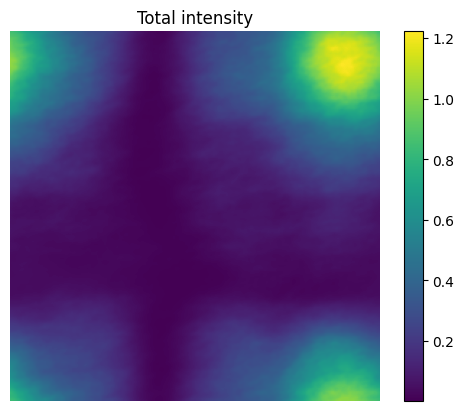

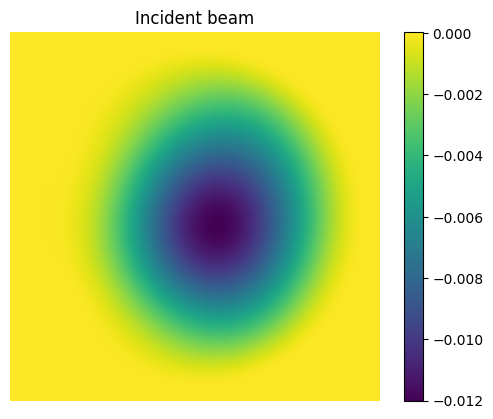

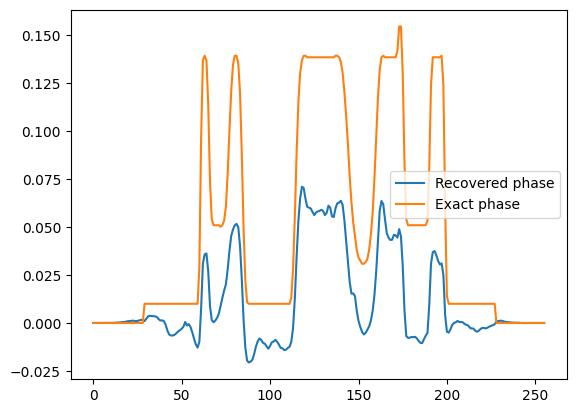

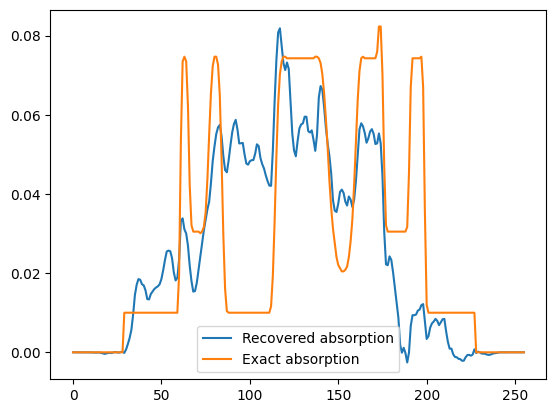

In [9]:
plt.figure()
plt.imshow(intens_tot)
plt.colorbar()
plt.axis('off')
plt.title('Total intensity')
plt.show()



plt.figure()
plt.imshow(Vcov[:,0].reshape(N, N).real/ np.linalg.norm(Vcov[:,0].reshape(N, N).real))
plt.colorbar()
plt.axis('off')
plt.title('Incident beam')
plt.show()

plt.figure()
plt.plot(sol_it[int(N/2), :].imag, label='Recovered phase')
plt.plot(contrast[int(N/2), :].imag, label='Exact phase')
plt.legend()
plt.show()

plt.figure()
plt.plot(sol_it[int(N/2), :].real, label='Recovered absorption')
plt.plot(contrast[int(N/2), :].real, label='Exact absorption')
plt.legend()
plt.show()
